# Exploratory data analysis (first pass)

Quick look at splits, labels, audio metadata, and speakers.

In [62]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [42]:
DATA_PATH = Path("data")

In [43]:
train_df = pd.read_csv(DATA_PATH / "train.csv")
dev_df = pd.read_csv(DATA_PATH / "dev.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv")
train_df.head()

,filename,transcription,spk_id,gender,ext,samplerate
0,train/0007c21c23.wav,139473,spk_E,female,wav,24000
1,train/000bee1b1d.wav,992597,spk_B,male,wav,24000
2,train/001a718902.wav,500869,spk_A,female,wav,22050
3,train/001e8e5565.wav,969908,spk_C,male,wav,22050
4,train/001ee5be6b.wav,80484,spk_E,female,wav,24000


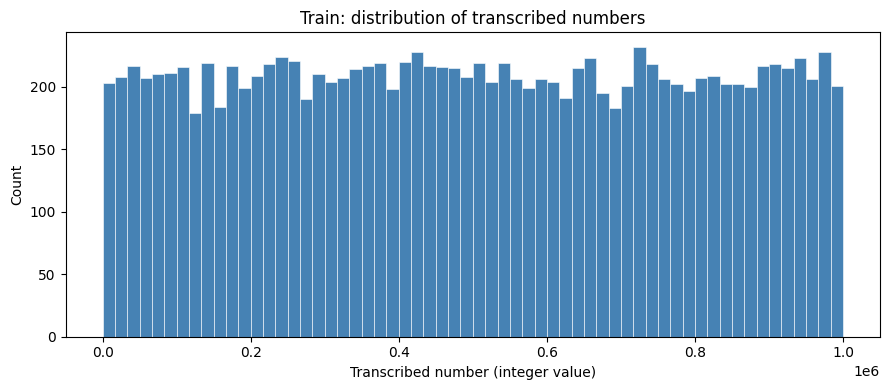

In [44]:
values = train_df["transcription"].astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(values, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Transcribed number (integer value)")
ax.set_ylabel("Count")
ax.set_title("Train: distribution of transcribed numbers")
plt.tight_layout()

In [45]:
dev_df.head()

,filename,transcription,spk_id,gender,ext,samplerate
0,dev/0025d6d9a9.wav,849905,spk_J,male,wav,16000
1,dev/0030479d60.mp3,967653,spk_I,female,mp3,16000
2,dev/003085d7a4.mp3,427524,spk_K,female,mp3,16000
3,dev/0047ca69ae.wav,93752,spk_H,male,wav,16000
4,dev/00b89e507d.mp3,43355,spk_I,female,mp3,16000


In [46]:
test_df.head()

,filename,ext,samplerate
0,test/d2440788a9.mp3,mp3,16000
1,test/e247dbf761.mp3,mp3,16000
2,test/071f4a5be7.mp3,mp3,16000
3,test/798bd15db7.mp3,mp3,16000
4,test/58c0464ad5.mp3,mp3,16000


In [47]:
total_n = len(train_df) + len(dev_df) + len(test_df)

print(f"Dataset sizes:\n  Train: {len(train_df):,}\n  Dev:   {len(dev_df):,}\n  Test:  {len(test_df):,}\n  Total: {total_n:,}\n")

print("Proportion of total samples:")
print(f"  Train: {100 * len(train_df) / total_n:.2f}%")
print(f"  Dev:   {100 * len(dev_df) / total_n:.2f}%")
print(f"  Test:  {100 * len(test_df) / total_n:.2f}%")

Dataset sizes:
  Train: 12,553
  Dev:   2,265
  Test:  2,582
  Total: 17,400

Proportion of total samples:
  Train: 72.14%
  Dev:   13.02%
  Test:  14.84%


In [48]:
train_df["gender"].value_counts()

gender
female    7665
male      4888
Name: count, dtype: int64

In [49]:
train_df["spk_id"].value_counts()

spk_id
spk_E    5686
spk_B    2914
spk_A    1066
spk_C    1063
spk_D     913
spk_F     911
Name: count, dtype: int64

In [50]:
for name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    na = df.isna().sum()
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    print("  missing:", na[na > 0].to_dict() if na.any() else "none")

print("\nTrain dtypes:\n", train_df.dtypes)

train: 12,553 rows × 6 cols
  missing: none
dev: 2,265 rows × 6 cols
  missing: none
test: 2,582 rows × 3 cols
  missing: none

Train dtypes:
 filename           str
transcription    int64
spk_id             str
gender             str
ext                str
samplerate       int64
dtype: object


In [51]:
def transcription_stats(df, name):
    s = df["transcription"].astype(str)
    lens = s.str.len()
    print(f"{name} — transcription string length (digits):")
    print(lens.describe())
    bad = ~s.str.fullmatch(r"\d+")
    if bad.any():
        print(f"  non-digit rows: {bad.sum()}")


transcription_stats(train_df, "train")
transcription_stats(dev_df, "dev")

train — transcription string length (digits):
count    12553.000000
mean         5.888553
std          0.353112
min          2.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          6.000000
Name: transcription, dtype: float64
dev — transcription string length (digits):
count    2265.000000
mean        5.891832
std         0.341801
min         4.000000
25%         6.000000
50%         6.000000
75%         6.000000
max         6.000000
Name: transcription, dtype: float64


In [52]:
for name, df in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    print(f"\n{name} — file extension:\n", df["ext"].value_counts().to_string())
    print(f"{name} — sample rate (Hz):\n", df["samplerate"].value_counts().sort_index().to_string())


train — file extension:
 ext
wav    12553
train — sample rate (Hz):
 samplerate
22050     2129
24000    10424

dev — file extension:
 ext
wav    1577
mp3     688
dev — sample rate (Hz):
 samplerate
16000    2265

test — file extension:
 ext
wav    1770
mp3     812
test — sample rate (Hz):
 samplerate
16000    2582


In [53]:
tr_spk = set(train_df["spk_id"])
dv_spk = set(dev_df["spk_id"])
print("Speakers: train", len(tr_spk), "| dev", len(dv_spk))
print("Dev speakers seen in train:", len(dv_spk & tr_spk), "of", len(dv_spk))
print("Dev-only:", sorted(dv_spk - tr_spk))
print("\nDev gender:\n", dev_df["gender"].value_counts().to_string())

Speakers: train 6 | dev 10
Dev speakers seen in train: 6 of 10
Dev-only: ['spk_H', 'spk_I', 'spk_J', 'spk_K']

Dev gender:
 gender
male      1277
female     988


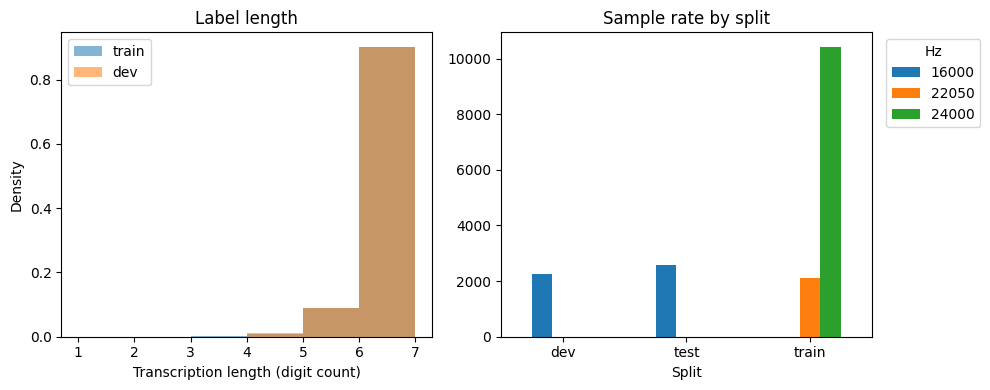

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

lt = train_df["transcription"].astype(str).str.len()
ld = dev_df["transcription"].astype(str).str.len()
max_len = int(max(lt.max(), ld.max()))
bins = range(1, max_len + 2)
axes[0].hist(lt, bins=bins, alpha=0.55, label="train", density=True)
axes[0].hist(ld, bins=bins, alpha=0.55, label="dev", density=True)
axes[0].set_xlabel("Transcription length (digit count)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].set_title("Label length")

sr = pd.concat(
    [
        train_df.assign(split="train"),
        dev_df.assign(split="dev"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)
pd.crosstab(sr["split"], sr["samplerate"]).plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Sample rate by split")
axes[1].set_xlabel("Split")
axes[1].legend(title="Hz", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

(array([1256., 1214., 1272., 1259., 1304., 1253., 1211., 1256., 1237.,
        1291.]),
 array([1.400000e+01, 1.000014e+05, 1.999888e+05, 2.999762e+05,
        3.999636e+05, 4.999510e+05, 5.999384e+05, 6.999258e+05,
        7.999132e+05, 8.999006e+05, 9.998880e+05]),
 <BarContainer object of 10 artists>)

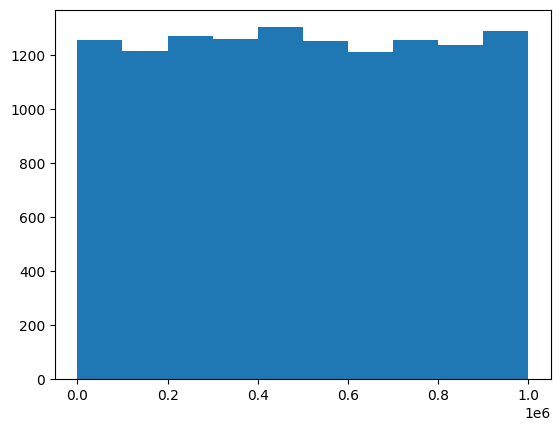

In [86]:
plt.hist(train_df["transcription"])

In [88]:
train_df["transcription"].max()

np.int64(999888)

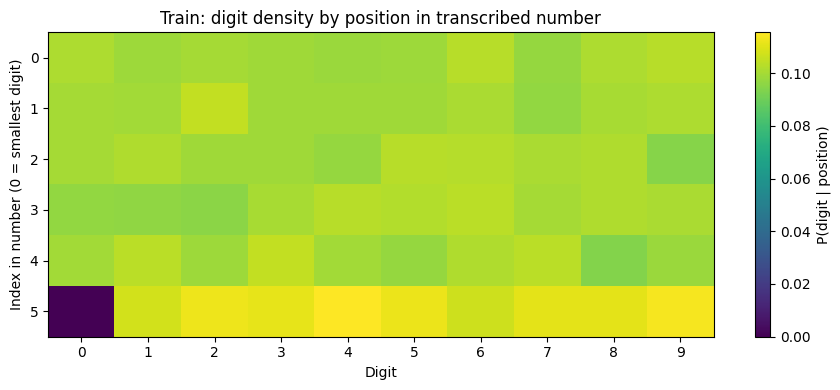

In [83]:
max_len_number = int(train_df["transcription"].astype(str).str.len().max())

numbers = train_df["transcription"].astype(str)
counts = np.zeros((max_len_number, 10), dtype=float)
for s in numbers:
    for j, ch in enumerate(s):
        counts[max_len_number - j - 1, int(ch)] += 1

row_sums = counts.sum(axis=1, keepdims=True)
density = np.divide(counts, row_sums, out=np.zeros_like(counts), where=row_sums > 0)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(density, aspect="auto", cmap="viridis", vmin=0, origin="upper")
ax.set_xlabel("Digit")
ax.set_ylabel("Index in number (0 = smallest digit)")
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(max_len_number))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("P(digit | position)")
ax.set_title("Train: digit density by position in transcribed number")
plt.tight_layout()